In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))
print(sys.path)

from BPMN.optimization import *
torch.set_default_dtype(torch.float64)
from libSOGAtruncate import truncate
import time

import torch
from torch.distributions import Normal, Categorical
import math

import BPMN.data_generating_process as dgp
import BPMN.helper_plots as hp
import matplotlib.pyplot as plt
import numpy as np


['/home/rdoz/miniconda3/envs/myenv/lib/python313.zip', '/home/rdoz/miniconda3/envs/myenv/lib/python3.13', '/home/rdoz/miniconda3/envs/myenv/lib/python3.13/lib-dynload', '', '/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages', '/home/rdoz/PhD/DeGAS/src']


/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [46]:
compiledFile=compile2SOGA('programs/debug.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

params = {
'mu0': 60., # START
'mu1': 20., # A_SUBMITTED
'mu2': 20., # A_PARTLYSUBMITTED
'mu3': 90., # W_Assess_fraud
'mu4': 120., # W_Fix_incomplete_submission
'mu5': 60., # A_PREACCEPTED
'mu6': 90., # W_Complete_preaccepted_appl

'p0': 0.9,
'p1': 0.3,
'p2': 0.3
}

for key in params:
    params[key] = params[key] ** 0.5

params_dict = initialize_params(params)
output_dist = start_SOGA(cfg, params_dict)


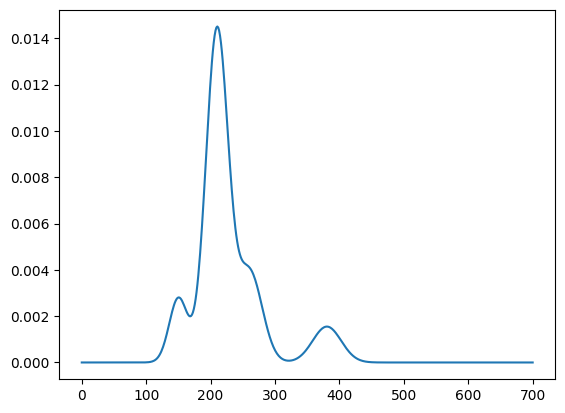

In [47]:
xs, pdf = hp.evaluate_marginal(output_dist, 't', 0, 700, 500)
plt.plot(xs.numpy(), pdf.numpy())

=== SOGA Model Output Distribution ===
SOGA mean (t): 60.0000
SOGA std (t):  10.0000

=== Simulator Output Distribution ===
Simulator mean (t): 222.0068
Simulator std (t):  58.9738

=== Comparison ===
Mean difference: 162.0068
Std difference:  48.9738


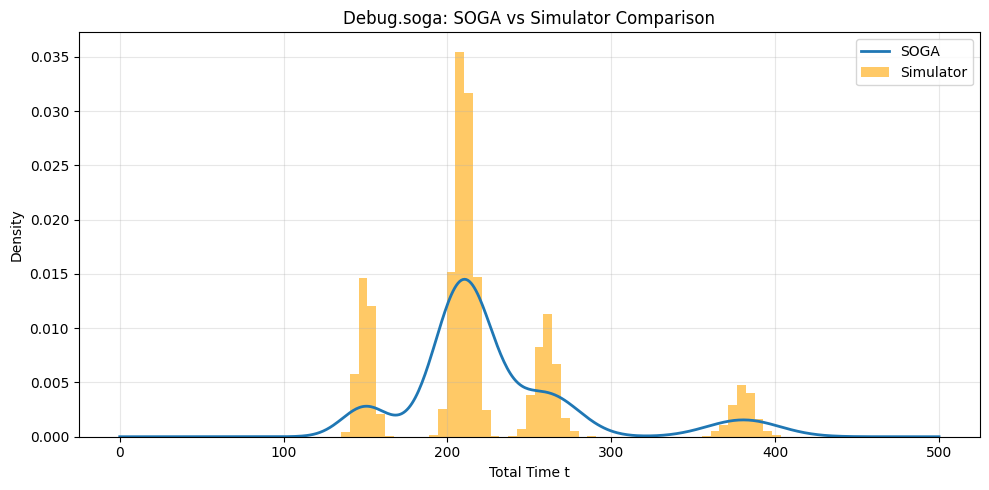

In [48]:
# Run simulator and compare with SOGA output
import sys
sys.path.insert(0, os.path.abspath('.'))
from debug_sim import run_samples, DEFAULT_PARAMS

sim_params = {
'mu0': 60., # START
'mu1': 20., # A_SUBMITTED
'mu2': 20., # A_PARTLYSUBMITTED
'mu3': 90., # W_Assess_fraud
'mu4': 120., # W_Fix_incomplete_submission
'mu5': 60., # A_PREACCEPTED
'mu6': 90., # W_Complete_preaccepted_appl

'p0': 0.9,
'p1': 0.3,
'p2': 0.3
}
# Generate samples from simulator
sim_samples = run_samples(n=5000, params=sim_params, seed=42)

# Print comparison
print("=== SOGA Model Output Distribution ===")
soga_mean = output_dist.gm.mean()[0].item()
soga_cov = output_dist.gm.cov()[0, 0].item()
print(f"SOGA mean (t): {soga_mean:.4f}")
print(f"SOGA std (t):  {np.sqrt(soga_cov):.4f}")

print("\n=== Simulator Output Distribution ===")
sim_mean = np.mean(sim_samples)
sim_std = np.std(sim_samples)
print(f"Simulator mean (t): {sim_mean:.4f}")
print(f"Simulator std (t):  {sim_std:.4f}")

print("\n=== Comparison ===")
print(f"Mean difference: {abs(soga_mean - sim_mean):.4f}")
print(f"Std difference:  {abs(np.sqrt(soga_cov) - sim_std):.4f}")

# Plot both distributions
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# SOGA marginal
xs_soga, pdf_soga = hp.evaluate_marginal(output_dist, 't', 0, 500, 500)
ax.plot(xs_soga.numpy(), pdf_soga.numpy(), label='SOGA', linewidth=2)

# Simulator histogram
ax.hist(sim_samples, bins=50, density=True, alpha=0.6, label='Simulator', color='orange')

ax.set_xlabel('Total Time t')
ax.set_ylabel('Density')
ax.set_title('Debug.soga: SOGA vs Simulator Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [49]:
output_dist.gm.pi.shape

torch.Size([7, 1])

In [13]:
compiledFile=compile2SOGA('programs/parallel_simpler.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

params = {
'mu0': 60., # START
'mu1': 20., # A_SUBMITTED
'mu2': 20., # A_PARTLYSUBMITTED
'mu3': 90., # W_Assess_fraud
'mu4': 120., # W_Fix_incomplete_submission
'mu5': 60., # A_PREACCEPTED
'mu6': 90., # W_Complete_preaccepted_appl
'mu7': 60., # A_ACCEPTED
'mu8': 60., # A_FINALIZED

'p0': 0.9,
'p1': 0.3,
'p2': 0.3,
'p3': 0.8,
'p4': 0.8,
'p5': 0.7
}

for key in params:
    params[key] = params[key] ** 0.5

params_dict = initialize_params(params)
output_dist = start_SOGA(cfg, params_dict)


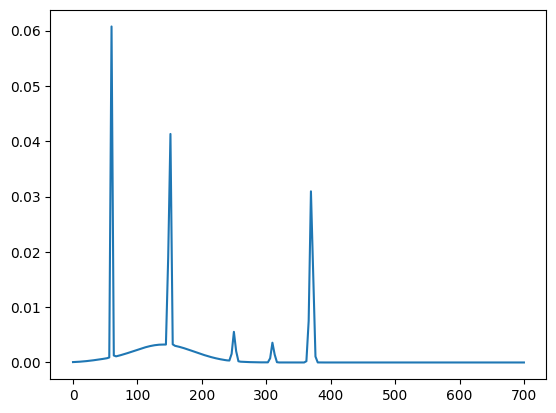

In [14]:
xs, pdf = hp.evaluate_marginal(output_dist, 't', 0, 700, 200)
plt.plot(xs.numpy(), pdf.numpy())

In [15]:
output_dist.gm.pi.shape

torch.Size([12, 1])

In [10]:
'''
if uniform([0., 1.], 2) - p4 < 0. {

            branch10 = branch01;
            branch11 = branch01;

            if uniform([0., 1.], 2) - p5 < 0. {
                endacts[5] = branch10 + tacts[5];
                branch10 = endacts[5];
            } else {
                skip;
            } end if;

            endacts[4] = branch11 + tacts[4];
            branch11 = endacts[4];

            if branch10 - branch11 < 0. {
                branch01 = branch11;
            } else {
                branch01 = branch10;
            } end if;
            prune(50);
        } else {
            skip;
        } end if;
'''

'\nif uniform([0., 1.], 2) - p4 < 0. {\n\n            branch10 = branch01;\n            branch11 = branch01;\n\n            if uniform([0., 1.], 2) - p5 < 0. {\n                endacts[5] = branch10 + tacts[5];\n                branch10 = endacts[5];\n            } else {\n                skip;\n            } end if;\n\n            endacts[4] = branch11 + tacts[4];\n            branch11 = endacts[4];\n\n            if branch10 - branch11 < 0. {\n                branch01 = branch11;\n            } else {\n                branch01 = branch10;\n            } end if;\n            prune(50);\n        } else {\n            skip;\n        } end if;\n'

In [11]:
output_dist.gm.pi.shape

torch.Size([32, 1])

=== SOGA Marginal (mixed) ===
SOGA mean (t): 60.0000
SOGA std  (t): 1.0000
=== Simulator ===
Sim mean (t): 163.0527
Sim std  (t): 107.1120
=== Differences ===
Mean diff: 103.0527
Std diff:  106.1120


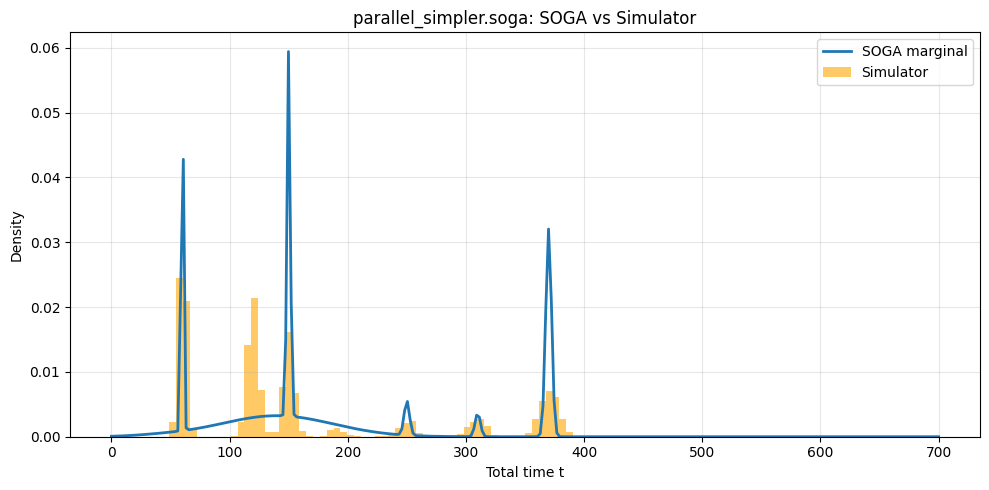

In [16]:
# Simulator for programs/parallel_simpler.soga and comparison with SOGA marginal
import numpy as np
from numpy.random import default_rng

# noise settings (match debug_sim assumptions)
ACT_NOISE_VAR = 10.0
P_NOISE_VAR = 0.1

def simulate_once_parallel(params, rng):
    # params: raw values as used in the notebook (before taking sqrt)
    _sqrt = np.sqrt
    # compute tacts (mean = raw mu value)
    tacts = [params[f'mu{i}'] + rng.normal(0.0, np.sqrt(ACT_NOISE_VAR)) for i in range(9)]
    tacts = [max(1e-8, x) for x in tacts]
    # gateway probabilities: compute _p = sqrt(raw), then p = _p*_p + noise, clip to [0,1]
    ps = []
    for j in range(6):
        raw = params[f'p{j}']
        _p = _sqrt(raw)
        p = _p * _p + rng.normal(0.0, np.sqrt(P_NOISE_VAR))
        p = min(1.0, max(0.0, p))
        ps.append(p)
    p0, p1, p2, p3, p4, p5 = ps

    # follow the SOGA program logic from parallel_simpler.soga
    t = 0.0
    endacts = [0.0] * 9

    if rng.uniform(0.0, 1.0) < p0:
        branch0 = t
        branch1 = t

        # Left outer branch
        if rng.uniform(0.0, 1.0) < p2:
            branch00 = branch0
            branch01 = branch0

            # branch00: A_FINALIZED -> tacts[0]
            endacts[0] = branch00 + tacts[0]
            branch00 = endacts[0]

            # branch01: O_SELECTED path -> tacts[1..3]
            endacts[1] = branch01 + tacts[1]
            branch01 = endacts[1]

            endacts[2] = branch01 + tacts[2]
            branch01 = endacts[2]

            endacts[3] = branch01 + tacts[3]
            branch01 = endacts[3]

            # optional inner parallel with p4 and optional tacts[5]/tacts[4]
            if rng.uniform(0.0, 1.0) < p4:
                branch10 = branch01
                branch11 = branch01

                if rng.uniform(0.0, 1.0) < p5:
                    endacts[5] = branch10 + tacts[5]
                    branch10 = endacts[5]
                # else skip

                endacts[4] = branch11 + tacts[4]
                branch11 = endacts[4]

                branch01 = branch11 if (branch10 - branch11) < 0. else branch10
            # else skip inner parallel

            # join inner parallel A_FINALIZED || O_SELECTED
            branch0 = branch01 if (branch00 - branch01) < 0. else branch00
        else:
            # skip left inner block
            pass

        # A_CANCELLED optional on left outer branch (tacts[7])
        if rng.uniform(0.0, 1.0) < p3:
            endacts[7] = branch0 + tacts[7]
            branch0 = endacts[7]

        # Right outer branch: O_CANCELLED optional (tacts[6])
        if rng.uniform(0.0, 1.0) < p1:
            endacts[6] = branch1 + tacts[6]
            branch1 = endacts[6]

        # join outer parallel -> t = max(branch0, branch1)
        t = branch1 if (branch0 - branch1) < 0. else branch0
    else:
        # skip outer parallel block
        pass

    # final activity tacts[8]
    endacts[8] = t + tacts[8]
    t = endacts[8]
    return float(t)

def run_samples_parallel(n, params, seed=None):
    rng = default_rng(seed)
    samples = np.empty(n, dtype=float)
    for i in range(n):
        samples[i] = simulate_once_parallel(params, rng)
    return samples

# Raw parameter values matching the notebook cell above (before sqrt)
sim_params = {
    'mu0': 60., 'mu1': 20., 'mu2': 20., 'mu3': 90., 'mu4': 120.,
    'mu5': 60., 'mu6': 90., 'mu7': 60., 'mu8': 60.,
    'p0': 0.9, 'p1': 0.3, 'p2': 0.3, 'p3': 0.8, 'p4': 0.8, 'p5': 0.7
}

# draw samples and compare to SOGA marginal in `output_dist`
n_samples = 5000
sim_samples = run_samples_parallel(n_samples, sim_params, seed=42)

# compute mixture mean and variance from SOGA `output_dist` (marginal 't')
gm = output_dist.gm
pi = gm.pi.detach().cpu().numpy().ravel()
means = output_dist.gm.mean()[0].item()
covs = output_dist.gm.cov()[0, 0].item()
soga_mean = (pi * means).sum()
soga_var = (pi * (covs + means**2)).sum() - soga_mean**2
soga_std = np.sqrt(max(0.0, soga_var))

print('=== SOGA Marginal (mixed) ===')
print(f'SOGA mean (t): {soga_mean:.4f}')
print(f'SOGA std  (t): {soga_std:.4f}')

print('=== Simulator ===')
print(f'Sim mean (t): {sim_samples.mean():.4f}')
print(f'Sim std  (t): {sim_samples.std():.4f}')

print('=== Differences ===')
print(f'Mean diff: {abs(soga_mean - sim_samples.mean()):.4f}')
print(f'Std diff:  {abs(soga_std - sim_samples.std()):.4f}')

# Plot comparison with SOGA marginal PDF
import matplotlib.pyplot as plt
xs, pdf = hp.evaluate_marginal(output_dist, 't', 0, 700, 300)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(xs.numpy(), pdf.numpy(), label='SOGA marginal', linewidth=2)
ax.hist(sim_samples, bins=60, density=True, alpha=0.6, label='Simulator', color='orange')
ax.set_xlabel('Total time t')
ax.set_ylabel('Density')
ax.set_title('parallel_simpler.soga: SOGA vs Simulator')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()